# Used Car Price-Value Ratio Arbitrage Study

**Question:** Which used cars in the SGD $60K–$80K bracket offer the best value?

**Data:** Used car listings from SGCarMart, fetched 2026-05-23.
Filters: 2016+ registration, passenger cars only, COE-renewed cars excluded.

In [1]:
import json, re
from datetime import datetime, date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR if (NB_DIR / "data").exists() else NB_DIR.parent
DATA_FILE = PROJECT_ROOT / "data/used_cars/sgd-passenger/latest.json"
CONFIG_FILE = PROJECT_ROOT / "data/used_cars/sgd-passenger/config.json"

with open(CONFIG_FILE) as f:
    watch_config = json.load(f)
print("Watch config:", json.dumps(watch_config, indent=2))

Watch config: {
  "name": "sgd-passenger",
  "filters": {
    "min_price": 60000,
    "max_price": 100000,
    "year_from": 2016,
    "vts": 2,
    "avl": "a",
    "sortby": "REG_DESC",
    "limit": 100
  },
  "max_pages": 50,
  "exclude_coe_renewed": true
}


In [2]:
with open(DATA_FILE) as f:
    raw = json.load(f)

listings = list(raw.values())
print(f"Loaded {len(listings)} listings")

# Derive reference date from the data itself
TODAY = datetime.strptime(listings[0]["posted_date"], "%d-%b-%Y").date()
YEAR_FROM = TODAY.year - 10
print(f"Reference date: {TODAY}, year_from: {YEAR_FROM}")
print(f"Fields: {list(listings[0].keys())}")

Loaded 2127 listings
Reference date: 2026-05-23, year_from: 2016
Fields: ['id', 'title', 'url', 'price', 'depreciation', 'reg_date', 'coe_left', 'mileage', 'eng_cap', 'owners', 'is_direct_owner', 'is_premium_ad', 'dealer', 'posted_date', 'description']


In [3]:
def parse_coe_left(text):
    if not text:
        return None
    years = 0.0
    y_match = re.search(r"(\d+)\s*y", text)
    m_match = re.search(r"(\d+)\s*m", text)
    if y_match:
        years += int(y_match.group(1))
    if m_match:
        years += int(m_match.group(1)) / 12
    return years if years > 0 else None


def parse_mileage(text):
    if not text:
        return None
    m = re.search(r"([\d,]+)", text)
    return float(m.group(1).replace(",", "")) if m else None


def parse_eng_cap(text):
    if not text:
        return None
    m = re.search(r"([\d,]+)", text)
    return float(m.group(1).replace(",", "")) if m else None


def parse_owners(text):
    if not text:
        return None
    if "more than" in text.lower():
        m = re.search(r"\d+", text)
        return int(m.group()) + 1 if m else None
    m = re.search(r"(\d+)\s*Owner", text)
    return int(m.group(1)) if m else None


def parse_reg_date(text):
    if not text:
        return None
    try:
        return datetime.strptime(text, "%d-%b-%Y").date()
    except ValueError:
        return None


def extract_brand(title):
    return title.split()[0] if title else ""


print("Parse functions ready.")

Parse functions ready.


In [4]:
rows = []
for car in listings:
    reg_date = parse_reg_date(car.get("reg_date"))
    age = (TODAY - reg_date).days / 365.25 if reg_date else None
    rows.append(
        {
            "id": car["id"],
            "title": car["title"],
            "brand": extract_brand(car["title"]),
            "price": car.get("price"),
            "depreciation": car.get("depreciation"),
            "reg_date": reg_date,
            "age_years": age,
            "coe_years_left": parse_coe_left(car.get("coe_left")),
            "mileage_km": parse_mileage(car.get("mileage")),
            "eng_cap_cc": parse_eng_cap(car.get("eng_cap")),
            "num_owners": parse_owners(car.get("owners")),
            "is_direct_owner": car.get("is_direct_owner", False),
            "is_premium_ad": car.get("is_premium_ad", False),
            "posted_date": datetime.strptime(car["posted_date"], "%d-%b-%Y").date() if car.get("posted_date") else None,
            "annual_mileage_km": (parse_mileage(car.get("mileage")) / age)
            if (age and age > 0 and car.get("mileage"))
            else None,
        }
    )

df = pd.DataFrame(rows)
print(f"DataFrame: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nNull counts:")
print(df.isnull().sum())
print(f"\nBasic stats:")
print(
    df[
        [
            "price",
            "depreciation",
            "age_years",
            "coe_years_left",
            "mileage_km",
            "eng_cap_cc",
            "num_owners",
            "annual_mileage_km",
        ]
    ].describe()
)

DataFrame: 2127 rows, 15 columns

Null counts:
id                     0
title                  0
brand                  0
price                  0
depreciation          26
reg_date               0
age_years              0
coe_years_left         6
mileage_km           172
eng_cap_cc            33
num_owners             1
is_direct_owner        0
is_premium_ad          0
posted_date            0
annual_mileage_km    172
dtype: int64

Basic stats:
               price  depreciation    age_years  coe_years_left  \
count    2127.000000   2101.000000  2127.000000     2121.000000   
mean    79664.726375  19343.607806     6.591033        3.379499   
std     11827.297320   4789.400114     1.294286        1.280956   
min     60000.000000  10640.000000     2.765229        0.166667   
25%     69000.000000  16130.000000     5.604381        2.500000   
50%     78800.000000  18330.000000     6.655715        3.333333   
75%     89800.000000  21460.000000     7.503080        4.333333   
max    100000.0

In [5]:
df["depreciation_rate"] = df["depreciation"] / df["price"]
df["est_original_price"] = df["price"] + (df["depreciation"] * df["age_years"])
df["value_retention"] = df["price"] / df["est_original_price"]
df["price_per_coe_year"] = df["price"] / df["coe_years_left"]
df["depreciation_per_cc"] = df["depreciation"] / df["eng_cap_cc"]

# Idea #2: Days on market — stale listings likely overpriced
df["days_on_market"] = df["posted_date"].apply(lambda d: (TODAY - d).days if pd.notna(d) else None)

# Idea #4: Price per owner — fewer owners = better maintained, lower $/owner is better
df["price_per_owner"] = np.where(
    df["num_owners"].notna() & (df["num_owners"] > 0), df["price"] / df["num_owners"], np.nan
)

# Idea #5: Depreciation per km driven — real-world cost-per-km of ownership
df["depreciation_per_km"] = np.where(
    df["annual_mileage_km"].notna() & (df["annual_mileage_km"] > 0),
    df["depreciation"] / df["annual_mileage_km"],
    np.nan,
)

df["suspicious"] = (
    (df["value_retention"] > 1.5)
    | (df["value_retention"] < 0.1)
    | (df["depreciation_rate"] > 1.0)
    | (df["age_years"] < 0)
)

print(f"Suspicious rows: {df['suspicious'].sum()} / {len(df)}")
clean = df[~df["suspicious"] & df["price"].notna() & df["depreciation"].notna()].copy()
print(f"Clean dataset: {len(clean)} listings")
print("\nValue characteristics summary:")
print(
    clean[
        [
            "depreciation_rate",
            "value_retention",
            "price_per_coe_year",
            "depreciation_per_cc",
            "days_on_market",
            "price_per_owner",
            "depreciation_per_km",
        ]
    ].describe()
)

Suspicious rows: 0 / 2127
Clean dataset: 2101 listings

Value characteristics summary:
       depreciation_rate  value_retention  price_per_coe_year  \
count        2101.000000      2101.000000         2101.000000   
mean            0.246563         0.397819        27652.583385   
std             0.063979         0.099691        15093.355650   
min             0.122745         0.126847        12000.000000   
25%             0.202116         0.325292        18541.176471   
50%             0.236221         0.388252        23285.714286   
75%             0.277030         0.470002        31466.666667   
max             0.735795         0.746592       169522.285714   

       depreciation_per_cc  days_on_market  price_per_owner  \
count          2068.000000     2101.000000      2100.000000   
mean             11.356143       13.003808     51633.266972   
std               2.257726       15.502872     24434.394827   
min               3.600504        0.000000     10214.285714   
25%         

In [6]:
# --- COE Data: load historical premiums & compute body-only value ---
import json, glob


def load_coe_premium_lookup():
    """Return dict: {(year_month, category): premium} from COE data files."""
    coe_dir = PROJECT_ROOT / "data/coe"
    records = []
    for f in sorted(glob.glob(str(coe_dir / "coe_results_*.json"))):
        with open(f) as fh:
            records.extend(json.load(fh))
    # Build lookup keyed by (year-month, category)
    lookup = {}
    for r in records:
        premium = r["premium"]
        if isinstance(premium, str):
            premium = int(premium.replace(",", ""))
        key = (r["month"], r["vehicle_class"])
        # Later bidding in same month overwrites (2nd bidding is the relevant one)
        lookup[key] = premium
    return lookup


coe_lookup = load_coe_premium_lookup()
print(f"COE lookup: {len(coe_lookup)} unique (month, category) entries")

# Get latest premiums for display
latest_premiums = {}
for (ym, cat), prem in coe_lookup.items():
    if cat not in latest_premiums or ym > latest_premiums[cat][0]:
        latest_premiums[cat] = (ym, prem)
latest_premiums = {cat: prem for cat, (ym, prem) in latest_premiums.items()}
print("Latest COE premiums:")
for cat, prem in sorted(latest_premiums.items()):
    print(f"  {cat}: ${prem:,.0f}")


# Assign COE category based on engine capacity
# Cat A: up to 1600cc (we lack power data, so this is a proxy)
# Cat B: above 1600cc
# Default: Cat A for EVs / missing eng_cap (most affordable EVs are Cat A)
def assign_coe_category(eng_cap_cc):
    if pd.isna(eng_cap_cc) or eng_cap_cc <= 1600:
        return "Category A"
    return "Category B"


clean["coe_category"] = clean["eng_cap_cc"].apply(assign_coe_category)


# Look up COE premium at registration time for each car
def get_reg_coe_premium(row):
    if row["reg_date"] is None:
        return None
    ym = row["reg_date"].strftime("%Y-%m")
    cat = row["coe_category"]
    return coe_lookup.get((ym, cat), None)


clean["reg_coe_premium"] = clean.apply(get_reg_coe_premium, axis=1)

# Fallback: use latest premium for cars where reg-month lookup failed
for cat in ["Category A", "Category B"]:
    mask = clean["reg_coe_premium"].isna() & (clean["coe_category"] == cat)
    clean.loc[mask, "reg_coe_premium"] = latest_premiums[cat]

missed = clean["reg_coe_premium"].isna().sum()
print(f"Cars with missing COE premium (after fallback): {missed}")

# Current COE premium for replacement-cost reference
clean["current_coe_premium"] = clean["coe_category"].map(latest_premiums)

# Remaining COE value = original premium x years_left / 10
# This is the correct pro-rated value of the COE that was actually paid
clean["est_coe_value"] = clean["reg_coe_premium"] * clean["coe_years_left"] / 10.0
clean["body_price"] = clean["price"] - clean["est_coe_value"]
clean["body_price_per_coe_year"] = clean["body_price"] / clean["coe_years_left"]

# COE annual depreciation = original premium / 10 (linear decay)
# Body depreciation = total annual depr - COE annual decay
clean["coe_annual_depreciation"] = clean["reg_coe_premium"] / 10.0
clean["body_depreciation"] = clean["depreciation"] - clean["coe_annual_depreciation"]
clean["body_depreciation_rate"] = clean["body_depreciation"] / clean["body_price"]

# Filter out nonsensical body values (e.g. cars priced below COE value)
clean = clean[clean["body_price"] > 5000].copy()

print(f"\nCOE category distribution:")
print(clean["coe_category"].value_counts())
print(f"\nReg-era COE premium vs current:")
print(clean[["reg_coe_premium", "current_coe_premium"]].describe())
print(f"\nBody-value metrics (n={len(clean)}):")
print(
    clean[
        ["est_coe_value", "body_price", "body_price_per_coe_year", "body_depreciation", "body_depreciation_rate"]
    ].describe()
)

COE lookup: 970 unique (month, category) entries
Latest COE premiums:
  Category A: $124,229
  Category B: $129,501
  Category C: $92,223
  Category D: $9,689
  Category E: $130,000
Cars with missing COE premium (after fallback): 0

COE category distribution:
coe_category
Category A    1122
Category B     979
Name: count, dtype: int64

Reg-era COE premium vs current:
       reg_coe_premium  current_coe_premium
count      2101.000000          2101.000000
mean      40551.607806        126685.586387
std       14415.415333          2630.513303
min       25000.000000        124229.000000
25%       32309.000000        124229.000000
50%       37010.000000        124229.000000
75%       44589.000000        129501.000000
max      129501.000000        129501.000000

Body-value metrics (n=2101):
       est_coe_value    body_price  body_price_per_coe_year  \
count    2101.000000   2101.000000              2101.000000   
mean    14481.458436  65222.179355             23597.422605   
std     10246.1

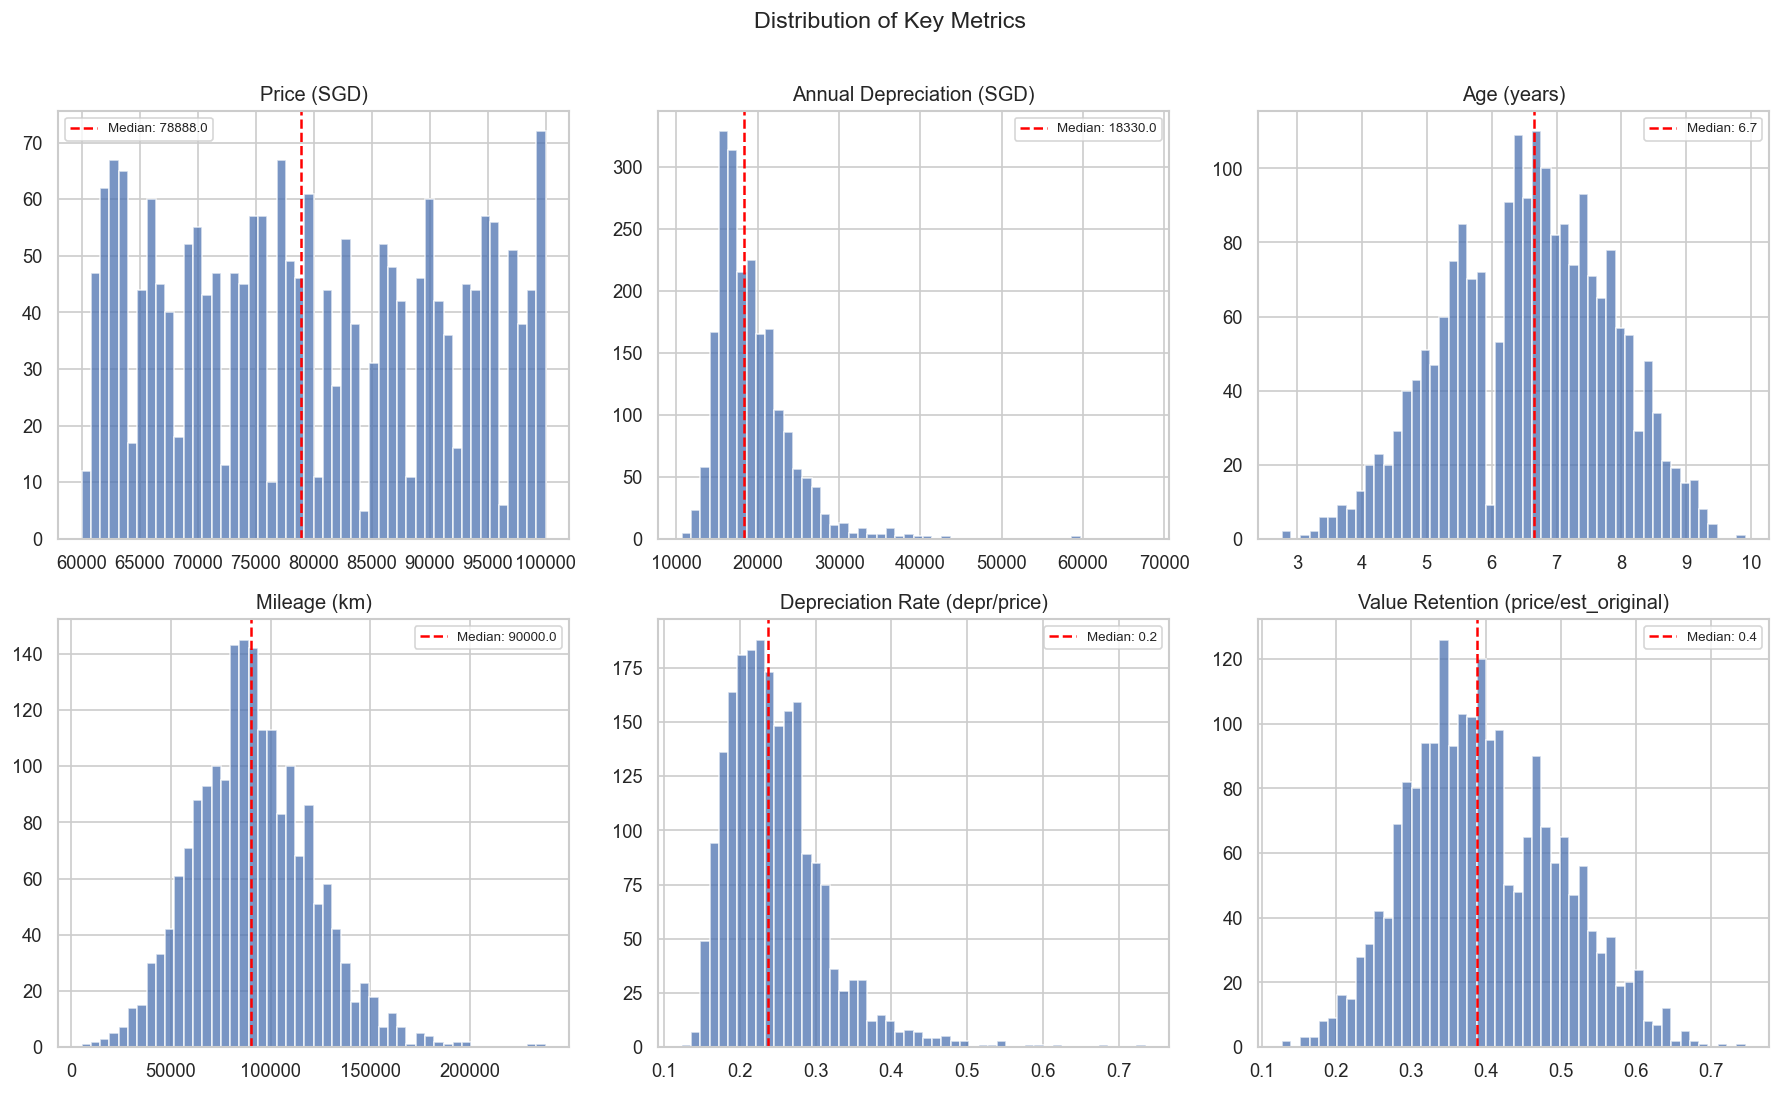

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
PRICE_LABEL = "Price (SGD)"
DEPRECIATION_LABEL = "Annual Depreciation (SGD)"

metrics = [
    ("price", PRICE_LABEL),
    ("depreciation", DEPRECIATION_LABEL),
    ("age_years", "Age (years)"),
    ("mileage_km", "Mileage (km)"),
    ("depreciation_rate", "Depreciation Rate (depr/price)"),
    ("value_retention", "Value Retention (price/est_original)"),
]
for ax, (col, label) in zip(axes, metrics):
    data = clean[col].dropna()
    ax.hist(data, bins=50, alpha=0.75, edgecolor="white")
    ax.axvline(data.median(), color="red", linestyle="--", linewidth=1.5, label=f"Median: {data.median():.1f}")
    ax.set_title(label)
    ax.legend(fontsize=8)
fig.suptitle("Distribution of Key Metrics", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

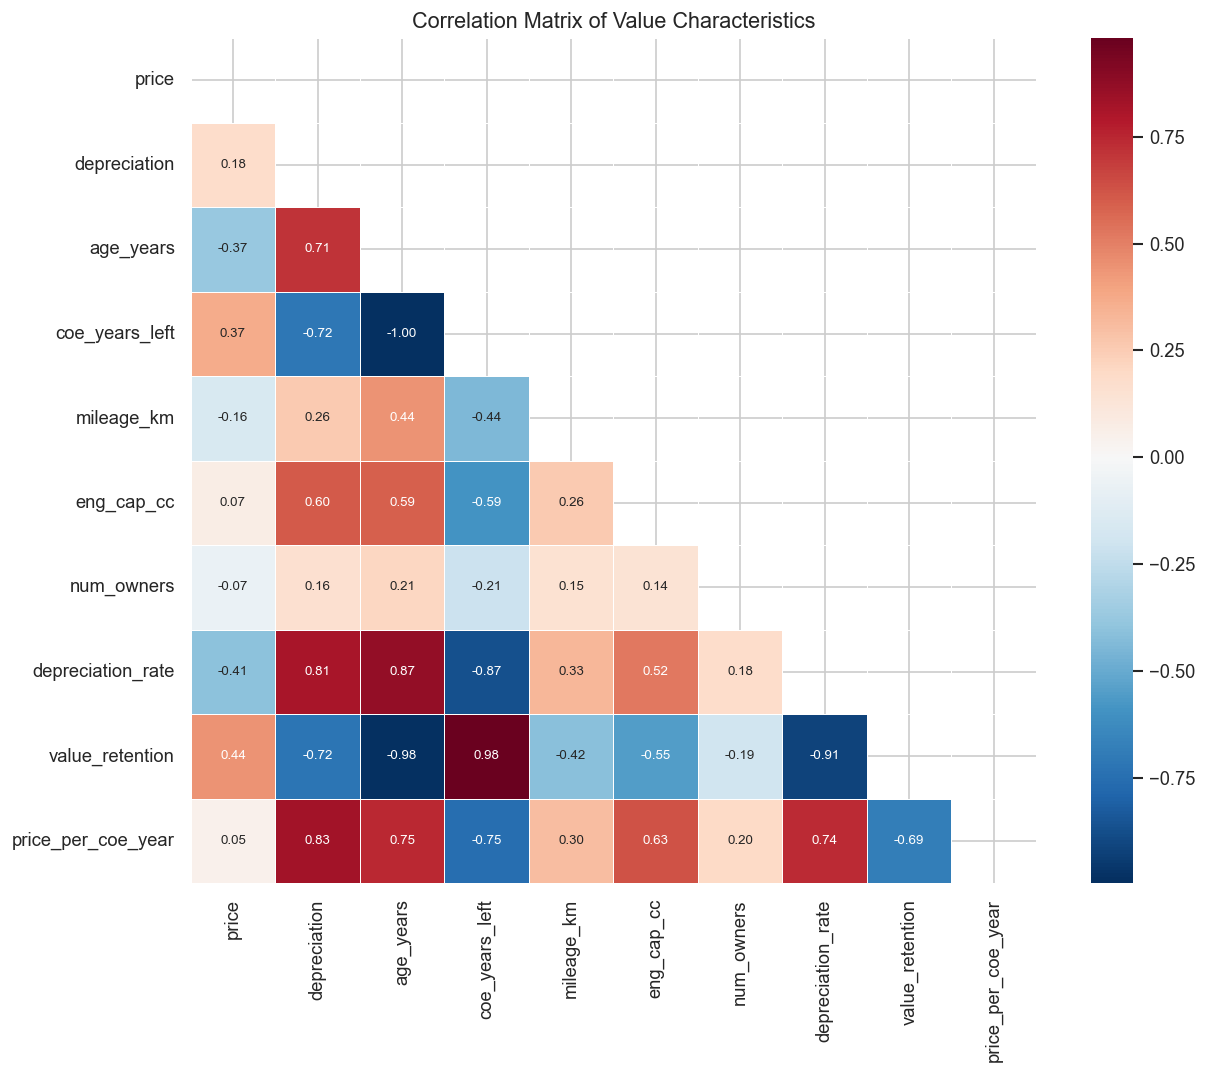

In [8]:
corr_cols = [
    "price",
    "depreciation",
    "age_years",
    "coe_years_left",
    "mileage_km",
    "eng_cap_cc",
    "num_owners",
    "depreciation_rate",
    "value_retention",
    "price_per_coe_year",
]
corr = clean[corr_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={"fontsize": 8},
)
ax.set_title("Correlation Matrix of Value Characteristics", fontsize=13)
plt.tight_layout()
plt.show()

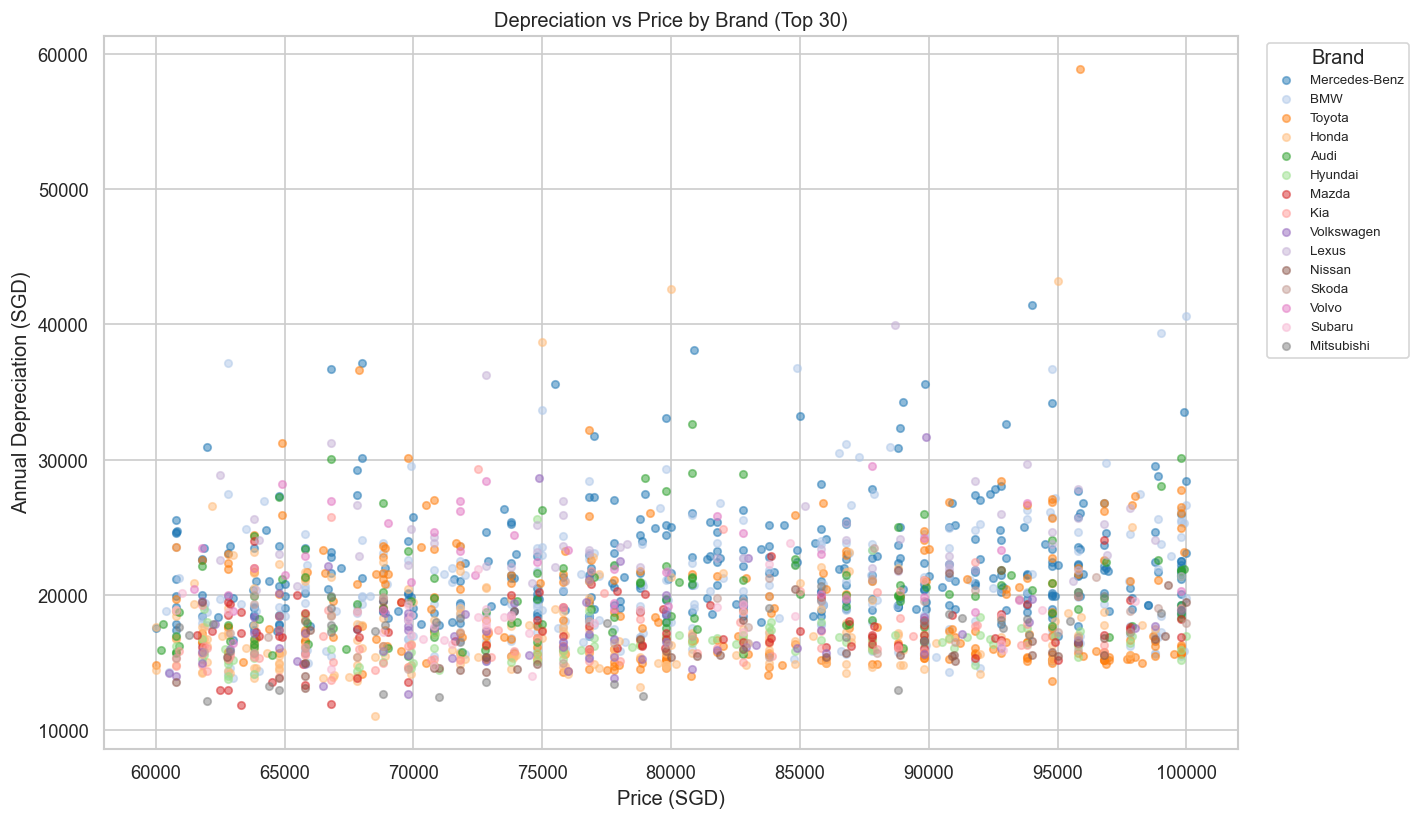

In [9]:
top_brands = clean["brand"].value_counts().head(15).index
plot_df = clean[clean["brand"].isin(top_brands)]
fig, ax = plt.subplots(figsize=(12, 7))
colors = sns.color_palette("tab20", len(top_brands))
for i, brand in enumerate(top_brands):
    brand_data = plot_df[plot_df["brand"] == brand]
    ax.scatter(brand_data["price"], brand_data["depreciation"], c=[colors[i]], label=brand, alpha=0.5, s=20)
ax.set_xlabel(PRICE_LABEL)
ax.set_ylabel(DEPRECIATION_LABEL)
ax.set_title("Depreciation vs Price by Brand (Top 30)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title="Brand")
plt.tight_layout()
plt.show()

In [10]:
print("## Top 30 — Lowest Depreciation Rate\n")
for i, (_, row) in enumerate(clean.nsmallest(30, "depreciation_rate").iterrows()):
    print(f"{i + 1}. **{row['title']}**")
    print(
        f"   Price: ${row['price']:,.0f} | Depr: ${row['depreciation']:,.0f}/yr ({row['depreciation_rate'] * 100:.1f}% of price)"
    )
    print(
        f"   Age: {row['age_years']:.1f}y | COE left: {row['coe_years_left']:.1f}y | Mileage: {row['mileage_km']:,.0f} km | Brand: {row['brand']}"
    )
    print()

## Top 30 — Lowest Depreciation Rate

1. **Peugeot 2008 1.2A PureTech EAT8 Allure Premium (OPC)**
   Price: $99,800 | Depr: $12,250/yr (12.3% of price)
   Age: 2.8y | COE left: 7.2y | Mileage: 20,500 km | Brand: Peugeot

2. **Opel Mokka 1.2A Turbo GS**
   Price: $99,800 | Depr: $13,630/yr (13.7% of price)
   Age: 2.9y | COE left: 7.1y | Mileage: 36,088 km | Brand: Opel

3. **Peugeot 3008 1.2A PureTech EAT8 Allure Premium**
   Price: $97,777 | Depr: $13,780/yr (14.1% of price)
   Age: 4.1y | COE left: 5.9y | Mileage: 131,752 km | Brand: Peugeot

4. **Opel Crossland 1.2A X Turbo**
   Price: $96,888 | Depr: $13,700/yr (14.1% of price)
   Age: 3.1y | COE left: 6.8y | Mileage: 24,783 km | Brand: Opel

5. **Toyota Yaris 1.0A XB**
   Price: $94,800 | Depr: $13,630/yr (14.4% of price)
   Age: 3.2y | COE left: 6.8y | Mileage: 43,000 km | Brand: Toyota

6. **Mitsubishi Space Star 1.2A**
   Price: $88,800 | Depr: $12,960/yr (14.6% of price)
   Age: 3.3y | COE left: 6.6y | Mileage: 5,200 km | Bran

In [11]:
print("## Top 30 — Highest Value Retention\n")
for i, (_, row) in enumerate(clean.nlargest(30, "value_retention").iterrows()):
    print(f"{i + 1}. **{row['title']}**")
    print(
        f"   Price: ${row['price']:,.0f} | Est Original: ${row['est_original_price']:,.0f} | Retention: {row['value_retention']:.1%}"
    )
    print(
        f"   Age: {row['age_years']:.1f}y | COE left: {row['coe_years_left']:.1f}y | Mileage: {row['mileage_km']:,.0f} km | Brand: {row['brand']}"
    )
    print()

## Top 30 — Highest Value Retention

1. **Peugeot 2008 1.2A PureTech EAT8 Allure Premium (OPC)**
   Price: $99,800 | Est Original: $133,674 | Retention: 74.7%
   Age: 2.8y | COE left: 7.2y | Mileage: 20,500 km | Brand: Peugeot

2. **Opel Mokka 1.2A Turbo GS**
   Price: $99,800 | Est Original: $138,833 | Retention: 71.9%
   Age: 2.9y | COE left: 7.1y | Mileage: 36,088 km | Brand: Opel

3. **Opel Crossland 1.2A X Turbo**
   Price: $96,888 | Est Original: $139,535 | Retention: 69.4%
   Age: 3.1y | COE left: 6.8y | Mileage: 24,783 km | Brand: Opel

4. **Toyota Yaris 1.0A XB**
   Price: $94,800 | Est Original: $138,871 | Retention: 68.3%
   Age: 3.2y | COE left: 6.8y | Mileage: 43,000 km | Brand: Toyota

5. **Opel Corsa-e Electric**
   Price: $87,800 | Est Original: $129,016 | Retention: 68.1%
   Age: 3.2y | COE left: 6.8y | Mileage: 72,000 km | Brand: Opel

6. **Citroen C4 1.2A PureTech Feel**
   Price: $93,800 | Est Original: $139,560 | Retention: 67.2%
   Age: 3.3y | COE left: 6.6y | Mil

In [12]:
print("## Top 30 — Lowest Price per COE Year\n")
for i, (_, row) in enumerate(clean.nsmallest(30, "price_per_coe_year").iterrows()):
    print(f"{i + 1}. **{row['title']}**")
    print(
        f"   Price: ${row['price']:,.0f} | COE left: {row['coe_years_left']:.1f}y | ${row['price_per_coe_year']:,.0f}/COE-year"
    )
    print(
        f"   Depr: ${row['depreciation']:,.0f}/yr | Age: {row['age_years']:.1f}y | Mileage: {row['mileage_km']:,.0f} km | Brand: {row['brand']}"
    )
    print()

## Top 30 — Lowest Price per COE Year

1. **Opel Corsa-e Electric**
   Price: $77,000 | COE left: 6.4y | $12,000/COE-year
   Depr: $11,970/yr | Age: 3.6y | Mileage: nan km | Brand: Opel

2. **Opel Corsa-e Electric**
   Price: $77,800 | COE left: 6.4y | $12,125/COE-year
   Depr: $12,100/yr | Age: 3.6y | Mileage: 83,217 km | Brand: Opel

3. **Opel Corsa-e Electric**
   Price: $80,000 | COE left: 6.6y | $12,152/COE-year
   Depr: $12,080/yr | Age: 3.4y | Mileage: nan km | Brand: Opel

4. **Opel Corsa-e Electric**
   Price: $78,800 | COE left: 6.4y | $12,281/COE-year
   Depr: $12,250/yr | Age: 3.6y | Mileage: nan km | Brand: Opel

5. **Opel Corsa-e Electric**
   Price: $77,800 | COE left: 6.3y | $12,284/COE-year
   Depr: $12,210/yr | Age: 3.6y | Mileage: nan km | Brand: Opel

6. **Opel Corsa-e Electric**
   Price: $79,000 | COE left: 6.4y | $12,312/COE-year
   Depr: $12,290/yr | Age: 3.6y | Mileage: 82,000 km | Brand: Opel

7. **Opel Corsa-e Electric**
   Price: $78,800 | COE left: 6.3y | $

In [13]:
print("## Top 30 — Lowest Body-Only Depreciation Rate\n")
print("Body depreciation = annual depreciation / (price - remaining COE value).")
print("Lower is better — isolates actual vehicle depreciation, excluding COE decay.\n")
for i, (_, row) in enumerate(clean.nsmallest(30, "body_depreciation_rate").iterrows()):
    print(f"{i + 1}. **{row['title']}** ({row['brand']})")
    print(
        f"   Price: ${row['price']:,.0f} | COE value: ${row['est_coe_value']:,.0f} | Body price: ${row['body_price']:,.0f}"
    )
    print(f"   Body depr rate: {row['body_depreciation_rate']:.1%} | Total depr rate: {row['depreciation_rate']:.1%}")
    print(f"   Age: {row['age_years']:.1f}y | COE left: {row['coe_years_left']:.1f}y | {row['coe_category']}")
    print()

## Top 30 — Lowest Body-Only Depreciation Rate

Body depreciation = annual depreciation / (price - remaining COE value).
Lower is better — isolates actual vehicle depreciation, excluding COE decay.

1. **Peugeot 2008 1.2A PureTech EAT8 Allure Premium (OPC)** (Peugeot)
   Price: $99,800 | COE value: $71,667 | Body price: $28,133
   Body depr rate: 8.0% | Total depr rate: 12.3%
   Age: 2.8y | COE left: 7.2y | Category A

2. **Suzuki Vitara 1.4A GLX** (Suzuki)
   Price: $72,800 | COE value: $49,692 | Body price: $23,108
   Body depr rate: 11.9% | Total depr rate: 20.8%
   Age: 6.0y | COE left: 4.0y | Category A

3. **Peugeot 3008 1.2A PureTech EAT8 Allure Premium** (Peugeot)
   Price: $97,777 | COE value: $40,647 | Body price: $57,130
   Body depr rate: 12.1% | Total depr rate: 14.1%
   Age: 4.1y | COE left: 5.9y | Category A

4. **BMW 1 Series 118i 5DR M-Sport** (BMW)
   Price: $90,800 | COE value: $49,692 | Body price: $41,108
   Body depr rate: 12.3% | Total depr rate: 19.3%
   Age: 5.

In [14]:
print("## Top 30 — Lowest Body Price per COE Year\n")
print("Body price per COE year = (price - COE value) / years left.")
print("This is what you actually pay per year for the vehicle, net of COE.\n")
for i, (_, row) in enumerate(clean.nsmallest(30, "body_price_per_coe_year").iterrows()):
    print(f"{i + 1}. **{row['title']}** ({row['brand']})")
    print(f"   Price: ${row['price']:,.0f} | COE value: ${row['est_coe_value']:,.0f} | Body: ${row['body_price']:,.0f}")
    print(f"   Body $/yr: ${row['body_price_per_coe_year']:,.0f} | Total $/yr: ${row['price_per_coe_year']:,.0f}")
    print(f"   Age: {row['age_years']:.1f}y | COE left: {row['coe_years_left']:.1f}y | {row['coe_category']}")
    print()

## Top 30 — Lowest Body Price per COE Year

Body price per COE year = (price - COE value) / years left.
This is what you actually pay per year for the vehicle, net of COE.

1. **Honda Jazz 1.3A** (Honda)
   Price: $61,800 | COE value: $49,692 | Body: $12,108
   Body $/yr: $3,027 | Total $/yr: $15,450
   Age: 5.9y | COE left: 4.0y | Category A

2. **Opel Corsa-e Electric** (Opel)
   Price: $80,000 | COE value: $56,617 | Body: $23,383
   Body $/yr: $3,552 | Total $/yr: $12,152
   Age: 3.4y | COE left: 6.6y | Category A

3. **Opel Corsa-e Electric** (Opel)
   Price: $87,800 | COE value: $63,115 | Body: $24,685
   Body $/yr: $3,657 | Total $/yr: $13,007
   Age: 3.2y | COE left: 6.8y | Category A

4. **Opel Crossland 1.2A X Turbo** (Opel)
   Price: $96,888 | COE value: $70,876 | Body: $26,012
   Body $/yr: $3,807 | Total $/yr: $14,179
   Age: 3.1y | COE left: 6.8y | Category A

5. **Opel Corsa-e Electric** (Opel)
   Price: $77,000 | COE value: $52,032 | Body: $24,968
   Body $/yr: $3,891 | 

Days on market stats: mean=13, median=7, max=65
Listings >30 days stale: 304 / 2101
Listings <=7 days fresh: 1111 / 2101

## Top 30 — Longest Days on Market (Likely Overpriced)

1. **Peugeot 3008 1.6A PureTech EAT8 Active** — 65 days on market
   $80,888 | Depr: 20.1% | Body depr: 19.3% | Age: 5.8y

2. **Nissan X-Trail 2.0A Premium 7-Seater Sunroof** — 65 days on market
   $96,800 | Depr: 17.4% | Body depr: 16.0% | Age: 5.1y

3. **BMW 2 Series 216i Gran Tourer** — 65 days on market
   $65,800 | Depr: 26.2% | Body depr: 24.9% | Age: 7.3y

4. **Honda Vezel 1.5A X** — 65 days on market
   $63,800 | Depr: 26.1% | Body depr: 25.3% | Age: 6.7y

5. **Lexus ES250 Executive** — 65 days on market
   $78,800 | Depr: 28.0% | Body depr: 26.6% | Age: 7.5y

6. **Mercedes-Benz GLC-Class GLC250 Coupe 4MATIC** — 65 days on market
   $98,888 | Depr: 29.1% | Body depr: 28.1% | Age: 7.6y

7. **Mercedes-Benz E-Class E250 Exclusive** — 65 days on market
   $67,997 | Depr: 31.3% | Body depr: 26.6% | Age: 8.6y

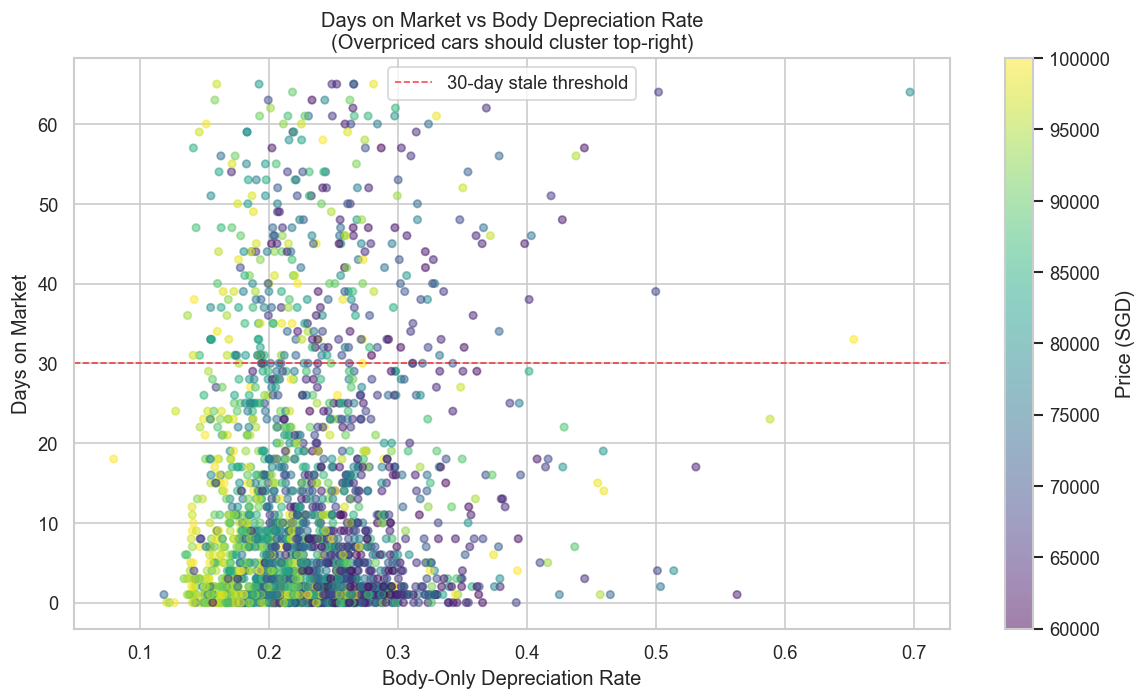

In [15]:
# --- Days on Market Analysis ---
dom_clean = clean[clean["days_on_market"].notna()].copy()

print(
    f"Days on market stats: mean={dom_clean['days_on_market'].mean():.0f}, "
    f"median={dom_clean['days_on_market'].median():.0f}, "
    f"max={dom_clean['days_on_market'].max():.0f}"
)
print(f"Listings >30 days stale: {(dom_clean['days_on_market'] > 30).sum()} / {len(dom_clean)}")
print(f"Listings <=7 days fresh: {(dom_clean['days_on_market'] <= 7).sum()} / {len(dom_clean)}")

# Top 30 Longest Days on Market (stale/overpriced)
print("\n## Top 30 — Longest Days on Market (Likely Overpriced)\n")
for i, (_, row) in enumerate(dom_clean.nlargest(30, "days_on_market").iterrows()):
    print(f"{i + 1}. **{row['title']}** — {row['days_on_market']:.0f} days on market")
    print(
        f"   ${row['price']:,.0f} | Depr: {row['depreciation_rate']:.1%} | "
        f"Body depr: {row['body_depreciation_rate']:.1%} | Age: {row['age_years']:.1f}y"
    )
    print()

# Top 30 Recently Posted Best Value (fresh <= 7 days, sorted by body_depreciation_rate)
fresh = dom_clean[dom_clean["days_on_market"] <= 7]
if len(fresh) > 0:
    print("## Top 30 — Recently Posted Best Value (Posted <= 7 Days)\n")
    print("Sorted by body-only depreciation rate (lowest = best vehicle value)\n")
    for i, (_, row) in enumerate(fresh.nsmallest(30, "body_depreciation_rate").iterrows()):
        print(f"{i + 1}. **{row['title']}** — Posted {row['days_on_market']:.0f} day(s) ago")
        print(
            f"   ${row['price']:,.0f} | Body depr: {row['body_depreciation_rate']:.1%} | "
            f"Total depr: {row['depreciation_rate']:.1%} | Age: {row['age_years']:.1f}y"
        )
        print()
else:
    print("No listings posted within the last 7 days.")

# Scatter: days_on_market vs body_depreciation_rate
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    dom_clean["body_depreciation_rate"],
    dom_clean["days_on_market"],
    c=dom_clean["price"],
    cmap="viridis",
    alpha=0.5,
    s=20,
)
ax.axhline(y=30, color="red", linestyle="--", alpha=0.7, linewidth=1, label="30-day stale threshold")
ax.set_xlabel("Body-Only Depreciation Rate")
ax.set_ylabel("Days on Market")
ax.set_title("Days on Market vs Body Depreciation Rate\n(Overpriced cars should cluster top-right)")
cbar = plt.colorbar(sc)
cbar.set_label(PRICE_LABEL)
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# --- Direct-Owner Discount Analysis ---
# Compare median prices between direct-owner and dealer listings
owner = clean[clean["is_direct_owner"] == True]
dealer = clean[clean["is_direct_owner"] == False]

print(f"Direct-owner listings: {len(owner)}")
print(f"Dealer listings: {len(dealer)}")

# Overall discount
if len(owner) >= 5 and len(dealer) >= 5:
    owner_med = owner["price"].median()
    dealer_med = dealer["price"].median()
    discount_pct = (dealer_med - owner_med) / dealer_med * 100
    print(f"\nOverall market:")
    print(f"  Dealer median price: ${dealer_med:,.0f}")
    print(f"  Direct-owner median price: ${owner_med:,.0f}")
    print(f"  Direct-owner discount: {discount_pct:.1f}%")
    if discount_pct > 0:
        print(f"  Direct-owner listings are {discount_pct:.1f}% cheaper on average")
    else:
        print(f"  Direct-owner listings are {-discount_pct:.1f}% MORE expensive (small sample bias likely)")
else:
    print("Insufficient data for overall comparison (need >=5 in both groups)")

# Per-brand comparison (brands with >=3 in both groups)
print(f"\n## Direct-Owner vs Dealer Price Comparison by Brand\n")
print(f"Only brands with >= 3 listings in both channels are shown.\n")
print(f"{'Brand':<20} {'Owner #':>7} {'Owner Med$':>11} {'Dealer #':>8} {'Dealer Med$':>11} {'Discount %':>10}")
print("-" * 72)

brand_discounts = []
for brand in sorted(clean["brand"].unique()):
    o = owner[owner["brand"] == brand]
    d = dealer[dealer["brand"] == brand]
    if len(o) >= 3 and len(d) >= 3:
        o_med = o["price"].median()
        d_med = d["price"].median()
        disc = (d_med - o_med) / d_med * 100
        brand_discounts.append({"brand": brand, "discount": disc, "owner_n": len(o), "dealer_n": len(d)})
        print(f"{brand:<20} {len(o):>7} ${o_med:>9,.0f} {len(d):>8} ${d_med:>9,.0f} {disc:>9.1f}%")

if not brand_discounts:
    print("No brands have sufficient data in both channels (need >=3 each).")
else:
    avg_disc = sum(d["discount"] for d in brand_discounts) / len(brand_discounts)
    positive = sum(1 for d in brand_discounts if d["discount"] > 0)
    print(f"\nAcross {len(brand_discounts)} brands with sufficient data:")
    print(f"  Average direct-owner discount: {avg_disc:.1f}%")
    print(f"  Brands where direct-owner IS cheaper: {positive}/{len(brand_discounts)}")

Direct-owner listings: 63
Dealer listings: 2038

Overall market:
  Dealer median price: $78,888
  Direct-owner median price: $76,888
  Direct-owner discount: 2.5%
  Direct-owner listings are 2.5% cheaper on average

## Direct-Owner vs Dealer Price Comparison by Brand

Only brands with >= 3 listings in both channels are shown.

Brand                Owner #  Owner Med$ Dealer # Dealer Med$ Discount %
------------------------------------------------------------------------
Audi                       4 $   66,800      119 $   79,800      16.3%
BMW                       11 $   78,888      263 $   79,555       0.8%
Honda                      6 $   84,750      212 $   73,884     -14.7%
Lexus                      3 $   69,888       56 $   80,844      13.6%
MINI                       3 $   75,800       27 $   69,800      -8.6%
Mercedes-Benz             19 $   76,888      316 $   82,800       7.1%
Toyota                     4 $   72,400      256 $   80,800      10.4%

Across 7 brands with suffic

Price per Owner stats (n=2100):
count     2100.000000
mean     51633.266972
std      24434.394827
min      10214.285714
25%      31987.666667
50%      43900.000000
75%      73800.000000
max      99999.000000
Name: price_per_owner, dtype: float64

## Top 30 — Best Price per Owner (Lowest $/Owner)

1. **Mercedes-Benz A-Class A250 AMG Line** — $10,214/owner (7 owner(s))
   $71,500 | Depr: 25.2% | Body depr: 23.4% | Age: 7.3y

2. **BMW M140i 5DR** — $10,467/owner (6 owner(s))
   $62,800 | Depr: 43.8% | Body depr: 39.8% | Age: 8.5y

3. **Kia Stinger 3.3A Sunroof** — $11,133/owner (6 owner(s))
   $66,800 | Depr: 38.5% | Body depr: 35.5% | Age: 8.4y

4. **Jaguar XE 2.0A** — $12,178/owner (5 owner(s))
   $60,888 | Depr: 24.5% | Body depr: 21.6% | Age: 7.1y

5. **Mercedes-Benz GLC-Class GLC250 AMG 4MATIC** — $12,300/owner (6 owner(s))
   $73,800 | Depr: 34.4% | Body depr: 32.4% | Age: 8.1y

6. **BMW X3 xDrive30i** — $12,400/owner (5 owner(s))
   $62,000 | Depr: 30.2% | Body depr: 26.9% | Age: 8

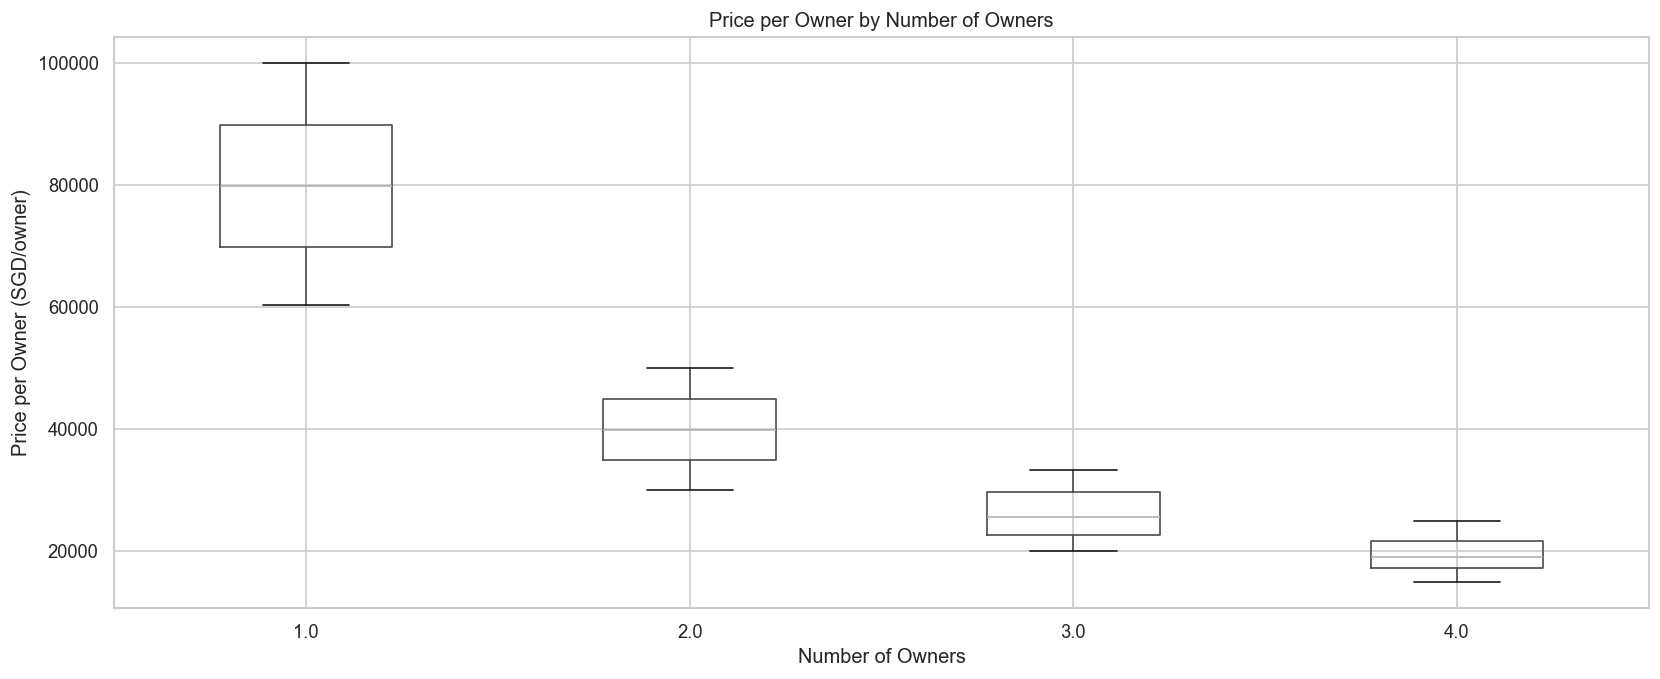

In [17]:
# --- Price per Owner Analysis ---
ppo_clean = clean[clean["price_per_owner"].notna()].copy()

print(f"Price per Owner stats (n={len(ppo_clean)}):")
print(ppo_clean["price_per_owner"].describe())

print("\n## Top 30 — Best Price per Owner (Lowest $/Owner)\n")
for i, (_, row) in enumerate(ppo_clean.nsmallest(30, "price_per_owner").iterrows()):
    print(f"{i + 1}. **{row['title']}** — ${row['price_per_owner']:,.0f}/owner ({int(row['num_owners'])} owner(s))")
    print(
        f"   ${row['price']:,.0f} | Depr: {row['depreciation_rate']:.1%} | "
        f"Body depr: {row['body_depreciation_rate']:.1%} | Age: {row['age_years']:.1f}y"
    )
    print()

# Boxplot: price_per_owner by num_owners (top 15 brands)
top_brands_ppo = ppo_clean["brand"].value_counts().head(15).index
ppo_plot = ppo_clean[ppo_clean["brand"].isin(top_brands_ppo) & (ppo_clean["num_owners"] <= 4)]
fig, ax = plt.subplots(figsize=(14, 6))
ppo_plot.boxplot(column="price_per_owner", by="num_owners", ax=ax)
ax.set_title("Price per Owner by Number of Owners")
ax.set_xlabel("Number of Owners")
ax.set_ylabel("Price per Owner (SGD/owner)")
plt.suptitle("")
plt.tight_layout()
plt.show()

Depreciation per KM stats (n=1936):
count    1936.000000
mean        1.546935
std         0.805899
min         0.254867
25%         1.076139
50%         1.356323
75%         1.790312
max        11.093081
Name: depreciation_per_km, dtype: float64

## Top 30 — Lowest Cost per KM (Best Value per Distance)

1. **Citroen C4 1.2A PureTech Feel** — $0.25/km
   $93,800 | Annual depr: $13,700/yr | Annual mileage: 53,753 km/yr | Age: 3.3y

2. **Ssangyong Tivoli Diesel 1.6A Standard** — $0.37/km
   $66,300 | Annual depr: $10,640/yr | Annual mileage: 28,802 km/yr | Age: 4.7y

3. **Toyota Sienta 1.5A X** — $0.41/km
   $99,500 | Annual depr: $15,660/yr | Annual mileage: 38,074 km/yr | Age: 3.8y

4. **Peugeot 3008 1.2A PureTech EAT8 Allure Premium** — $0.43/km
   $97,777 | Annual depr: $13,780/yr | Annual mileage: 32,362 km/yr | Age: 4.1y

5. **Volkswagen Golf 1.4A TSI Comfortline R-Line** — $0.47/km
   $77,800 | Annual depr: $15,450/yr | Annual mileage: 32,978 km/yr | Age: 5.6y

6. **Honda Freed Hyb

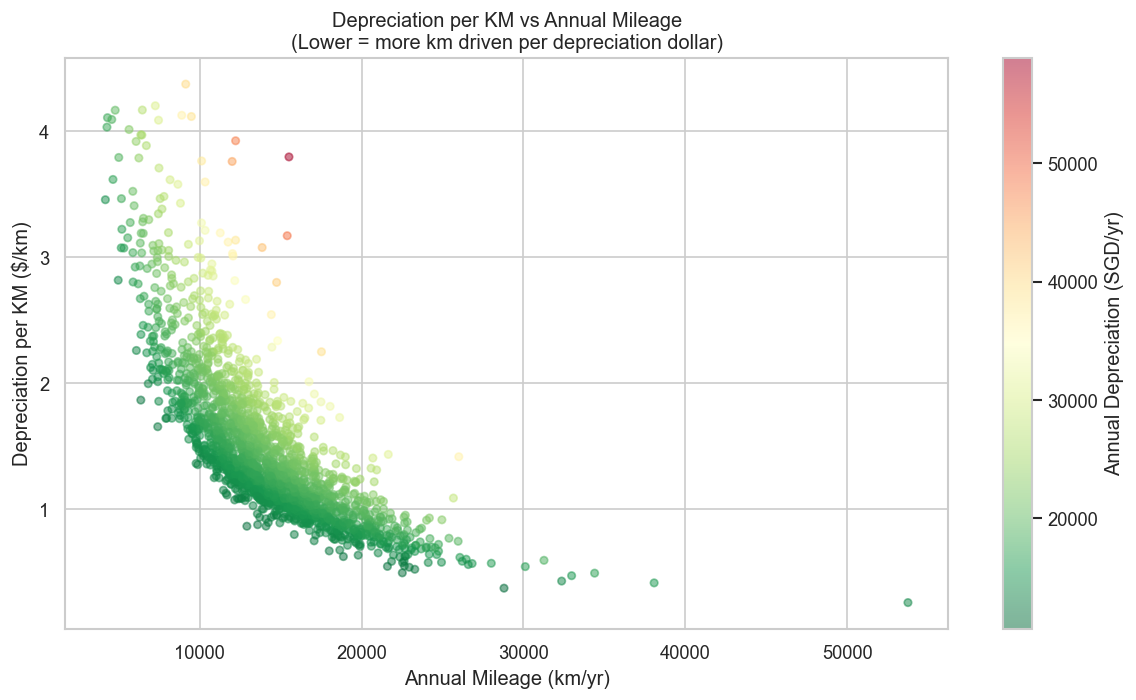

In [18]:
# --- Depreciation per KM Driven Analysis ---
dpk_clean = clean[clean["depreciation_per_km"].notna()].copy()

print(f"Depreciation per KM stats (n={len(dpk_clean)}):")
print(dpk_clean["depreciation_per_km"].describe())

# Filter outliers: cap at 99th percentile for display
cap = dpk_clean["depreciation_per_km"].quantile(0.99)

print("\n## Top 30 — Lowest Cost per KM (Best Value per Distance)\n")
for i, (_, row) in enumerate(dpk_clean.nsmallest(30, "depreciation_per_km").iterrows()):
    print(f"{i + 1}. **{row['title']}** — ${row['depreciation_per_km']:.2f}/km")
    print(
        f"   ${row['price']:,.0f} | Annual depr: ${row['depreciation']:,.0f}/yr | "
        f"Annual mileage: {row['annual_mileage_km']:,.0f} km/yr | Age: {row['age_years']:.1f}y"
    )
    print()

# Scatter: depreciation_per_km vs annual_mileage_km
fig, ax = plt.subplots(figsize=(10, 6))
plot_data = dpk_clean[dpk_clean["depreciation_per_km"] <= cap]
sc = ax.scatter(
    plot_data["annual_mileage_km"],
    plot_data["depreciation_per_km"],
    c=plot_data["depreciation"],
    cmap="RdYlGn_r",
    alpha=0.5,
    s=20,
)
ax.set_xlabel("Annual Mileage (km/yr)")
ax.set_ylabel("Depreciation per KM ($/km)")
ax.set_title("Depreciation per KM vs Annual Mileage\n(Lower = more km driven per depreciation dollar)")
cbar = plt.colorbar(sc)
cbar.set_label("Annual Depreciation (SGD/yr)")
plt.tight_layout()
plt.show()

In [19]:
brand_stats = (
    clean.groupby("brand")
    .agg(
        count=("id", "count"),
        median_price=("price", "median"),
        median_depreciation_rate=("depreciation_rate", "median"),
        median_value_retention=("value_retention", "median"),
        median_price_per_coe_year=("price_per_coe_year", "median"),
        median_age=("age_years", "median"),
        median_mileage=("mileage_km", "median"),
    )
    .query("count >= 10")
    .sort_values("median_depreciation_rate")
)

print("## Brand Value Rankings (min 10 listings)\n")
print(f"{'Brand':<20} {'#':>4} {'Med Price':>10} {'Med DeprRate':>11} {'Med Retention':>12} {'Med $/COEyr':>11}")
print("-" * 72)
for brand, row in brand_stats.iterrows():
    print(
        f"{brand:<20} {int(row['count']):>4} ${row['median_price']:>8,.0f} "
        f"{row['median_depreciation_rate']:>10.1%} {row['median_value_retention']:>11.1%} "
        f"${row['median_price_per_coe_year']:>9,.0f}"
    )
print()
print("## Top 30 Brands by Lowest Depreciation Rate")
for i, (brand, row) in enumerate(brand_stats.head(10).iterrows()):
    print(
        f"{i + 1}. **{brand}** — {row['median_depreciation_rate']:.1%} depr rate, "
        f"{row['median_value_retention']:.1%} retention, "
        f"${row['median_price']:,.0f} median price ({int(row['count'])} listings)"
    )

## Brand Value Rankings (min 10 listings)

Brand                   #  Med Price Med DeprRate Med Retention Med $/COEyr
------------------------------------------------------------------------
Opel                   29 $  77,800      15.7%       63.7% $   14,151
Citroen                19 $  89,800      16.4%       58.9% $   17,411
Peugeot                27 $  85,955      17.3%       52.8% $   18,844
MG                     17 $  89,800      18.9%       50.4% $   18,905
Nissan                 49 $  82,800      20.0%       48.2% $   17,158
Suzuki                 18 $  74,400      20.5%       46.6% $   17,395
Mitsubishi             40 $  75,150      20.6%       46.3% $   20,987
Hyundai                97 $  80,300      20.7%       47.0% $   17,511
Mazda                  86 $  78,944      20.7%       45.4% $   19,735
SEAT                   14 $  70,400      21.1%       44.9% $   19,542
Honda                 218 $  73,938      22.3%       43.3% $   18,979
Kia                    75 $  73,300   

In [20]:
scoring = (
    clean[
        [
            "depreciation_rate",
            "value_retention",
            "price_per_coe_year",
            "body_depreciation_rate",
            "body_price_per_coe_year",
            "mileage_km",
            "age_years",
            "days_on_market",
            "price_per_owner",
            "depreciation_per_km",
        ]
    ]
    .dropna()
    .copy()
)

# Annual mileage — normalises wear against age. Cap at 50,000 km/yr.
scoring["annual_mileage"] = scoring["mileage_km"] / scoring["age_years"]
am_cap = 50000
scoring["annual_mileage"] = scoring["annual_mileage"].clip(upper=am_cap)

# Normalise all metrics to 0-1 range
d_min, d_max = scoring["depreciation_rate"].min(), scoring["depreciation_rate"].max()
r_min, r_max = scoring["value_retention"].min(), scoring["value_retention"].max()
p_min, p_max = scoring["price_per_coe_year"].min(), scoring["price_per_coe_year"].max()
bd_min, bd_max = scoring["body_depreciation_rate"].min(), scoring["body_depreciation_rate"].max()
bp_min, bp_max = scoring["body_price_per_coe_year"].min(), scoring["body_price_per_coe_year"].max()
m_min, m_max = scoring["annual_mileage"].min(), scoring["annual_mileage"].max()
dpm_min, dpm_max = scoring["depreciation_per_km"].min(), scoring["depreciation_per_km"].max()
ppo_min, ppo_max = scoring["price_per_owner"].min(), scoring["price_per_owner"].max()
dom_min, dom_max = scoring["days_on_market"].min(), scoring["days_on_market"].max()

scoring["depr_score"] = 1 - (scoring["depreciation_rate"] - d_min) / (d_max - d_min)
scoring["retention_score"] = (scoring["value_retention"] - r_min) / (r_max - r_min)
scoring["body_depr_score"] = 1 - (scoring["body_depreciation_rate"] - bd_min) / (bd_max - bd_min)
scoring["body_ppy_score"] = 1 - (scoring["body_price_per_coe_year"] - bp_min) / (bp_max - bp_min)
scoring["mileage_score"] = 1 - (scoring["annual_mileage"] - m_min) / (m_max - m_min)
scoring["depr_per_km_score"] = 1 - (scoring["depreciation_per_km"] - dpm_min) / (dpm_max - dpm_min)
scoring["price_per_owner_score"] = 1 - (scoring["price_per_owner"] - ppo_min) / (ppo_max - ppo_min)
scoring["days_market_score"] = 1 - (scoring["days_on_market"] - dom_min) / (dom_max - dom_min)

# Composite score: body-depr gets highest weight — it reveals true vehicle value
# New metrics added: depr_per_km (10%), price_per_owner (5%), days_on_market (5%)
scoring["composite_score"] = (
    scoring["body_depr_score"] * 0.25
    + scoring["retention_score"] * 0.20
    + scoring["body_ppy_score"] * 0.15
    + scoring["depr_score"] * 0.10
    + scoring["mileage_score"] * 0.10
    + scoring["depr_per_km_score"] * 0.10
    + scoring["price_per_owner_score"] * 0.05
    + scoring["days_market_score"] * 0.05
)

clean_scored = clean.loc[scoring.index].copy()
clean_scored["composite_score"] = scoring["composite_score"]
clean_scored["annual_mileage"] = scoring["annual_mileage"]

print("## Top 30 — Composite Value Score (COE-Adjusted)\n")
print(
    "Score = 0.25 x body_depr + 0.20 x retention + 0.15 x body_ppy + 0.10 x total_depr + 0.10 x mileage + 0.10 x depr_per_km + 0.05 x price_per_owner + 0.05 x days_on_market\n"
)
for i, (_, row) in enumerate(clean_scored.nlargest(30, "composite_score").iterrows()):
    print(f"{i + 1}. **{row['title']}** ({row['brand']}) — Score: {row['composite_score']:.3f}")
    print(f"   ${row['price']:,.0f} | COE: ${row['est_coe_value']:,.0f} | Body: ${row['body_price']:,.0f}")
    print(
        f"   Body depr rate: {row['body_depreciation_rate']:.1%} | Total depr rate: {row['depreciation_rate']:.1%} | "
        f"Retention: {row['value_retention']:.1%}"
    )
    print(
        f"   Body $/yr: ${row['body_price_per_coe_year']:,.0f} | Age: {row['age_years']:.1f}y | "
        f"COE left: {row['coe_years_left']:.1f}y | {row['coe_category']}"
    )
    print()

## Top 30 — Composite Value Score (COE-Adjusted)

Score = 0.25 x body_depr + 0.20 x retention + 0.15 x body_ppy + 0.10 x total_depr + 0.10 x mileage + 0.10 x depr_per_km + 0.05 x price_per_owner + 0.05 x days_on_market

1. **Peugeot 2008 1.2A PureTech EAT8 Allure Premium (OPC)** (Peugeot) — Score: 0.910
   $99,800 | COE: $71,667 | Body: $28,133
   Body depr rate: 8.0% | Total depr rate: 12.3% | Retention: 74.7%
   Body $/yr: $3,926 | Age: 2.8y | COE left: 7.2y | Category A

2. **Opel Mokka 1.2A Turbo GS** (Opel) — Score: 0.888
   $99,800 | COE: $67,435 | Body: $32,365
   Body depr rate: 12.7% | Total depr rate: 13.7% | Retention: 71.9%
   Body $/yr: $4,569 | Age: 2.9y | COE left: 7.1y | Category A

3. **Opel Mokka 1.2A Turbo GS** (Opel) — Score: 0.880
   $90,800 | COE: $58,128 | Body: $32,672
   Body depr rate: 13.8% | Total depr rate: 15.0% | Retention: 65.6%
   Body $/yr: $5,092 | Age: 3.5y | COE left: 6.4y | Category A

4. **Toyota Yaris 1.0A XB** (Toyota) — Score: 0.870
   $94,800 

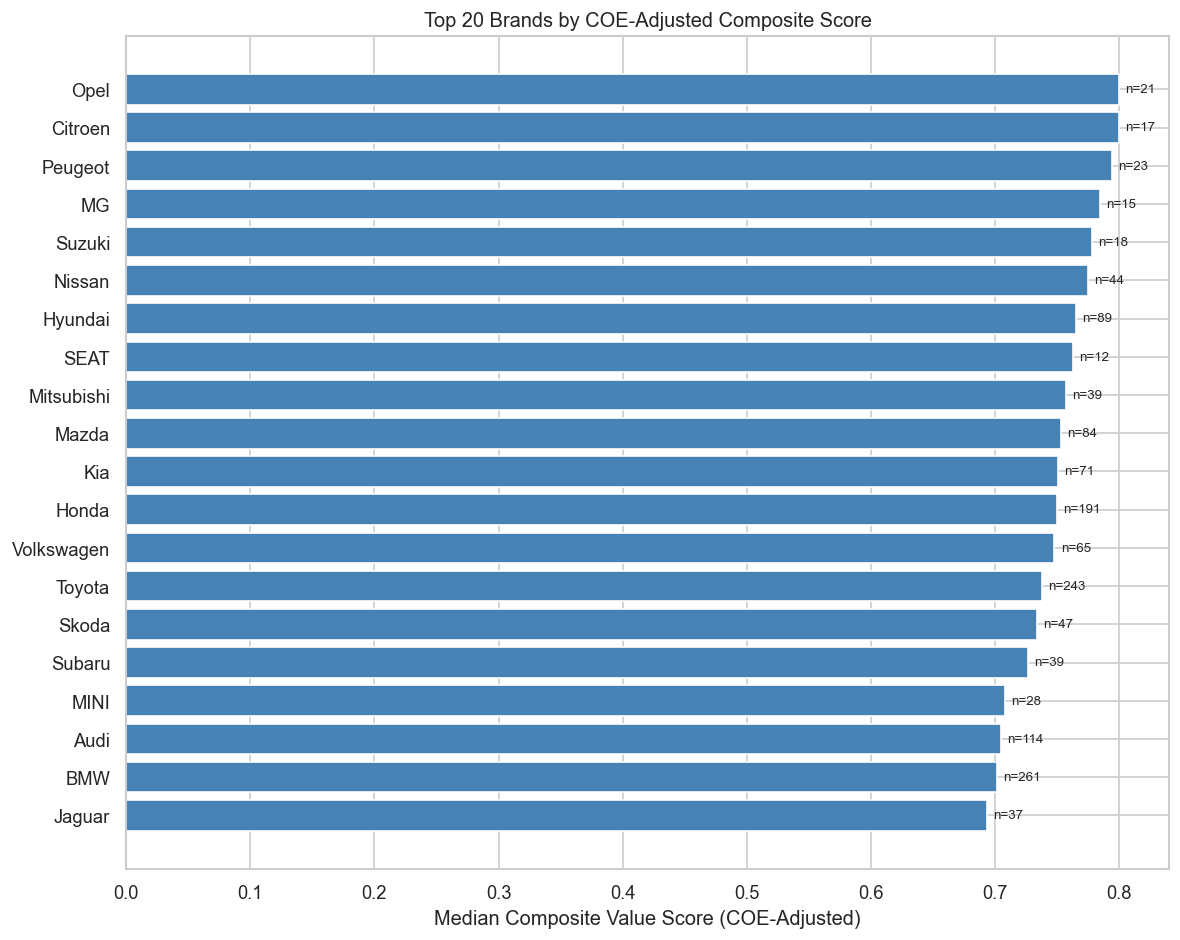

## Brand Value Rankings — COE-Adjusted Composite Score (min 10 listings)

Brand                   #  Med Price Med BodyDepr Med Body$/yr  Med Score
------------------------------------------------------------------------
Opel                   21 $  76,800       17.8% $    9,933     0.800
Citroen                17 $  90,800       15.8% $   12,734     0.800
Peugeot                23 $  85,955       16.3% $   15,362     0.794
MG                     15 $  89,800       18.2% $   14,446     0.784
Suzuki                 18 $  74,400       19.6% $   13,429     0.778
Nissan                 44 $  81,444       19.4% $   12,958     0.775
Hyundai                89 $  79,800       20.3% $   13,456     0.765
SEAT                   12 $  73,700       20.5% $   16,420     0.763
Mitsubishi             39 $  72,800       20.0% $   17,154     0.757
Mazda                  84 $  78,944       20.2% $   16,024     0.753
Kia                    71 $  73,300       20.9% $   14,409     0.751
Honda               

In [21]:
brand_composite = (
    clean_scored.groupby("brand")
    .agg(
        count=("id", "count"),
        median_score=("composite_score", "median"),
        median_price=("price", "median"),
        median_body_depr=("body_depreciation_rate", "median"),
        median_body_ppy=("body_price_per_coe_year", "median"),
        median_depr_rate=("depreciation_rate", "median"),
        median_retention=("value_retention", "median"),
    )
    .query("count >= 10")
    .sort_values("median_score", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(brand_composite))
plot_brands = brand_composite.head(top_n)
ax.barh(range(len(plot_brands)), plot_brands["median_score"], color="steelblue")
ax.set_yticks(range(len(plot_brands)))
ax.set_yticklabels(plot_brands.index)
ax.invert_yaxis()
ax.set_xlabel("Median Composite Value Score (COE-Adjusted)")
ax.set_title(f"Top {top_n} Brands by COE-Adjusted Composite Score")
for i, (_, row) in enumerate(plot_brands.iterrows()):
    ax.text(row["median_score"] + 0.005, i, f"n={int(row['count'])}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

print("## Brand Value Rankings — COE-Adjusted Composite Score (min 10 listings)\n")
print(f"{'Brand':<20} {'#':>4} {'Med Price':>10} {'Med BodyDepr':>12} {'Med Body$/yr':>11} {'Med Score':>10}")
print("-" * 72)
for brand, row in brand_composite.iterrows():
    print(
        f"{brand:<20} {int(row['count']):>4} ${row['median_price']:>8,.0f} "
        f"{row['median_body_depr']:>11.1%} ${row['median_body_ppy']:>9,.0f} "
        f"{row['median_score']:>9.3f}"
    )
print()
print("## Top 10 Brands by COE-Adjusted Composite Score")
for i, (brand, row) in enumerate(brand_composite.head(10).iterrows()):
    print(
        f"{i + 1}. **{brand}** — Score: {row['median_score']:.3f} | "
        f"Body depr: {row['median_body_depr']:.1%} | "
        f"Body $/yr: ${row['median_body_ppy']:,.0f} | "
        f"${row['median_price']:,.0f} median ({int(row['count'])} listings)"
    )

## Summary & Caveats

### Data Filters Applied
- Price bracket: SGD $60K–$100K
- Registration year >= 2016 (API filter)
- Vehicle type: All Passenger Cars (`vts=2`) — excludes vans/commercial
- COE-renewed cars excluded (title-based post-filter)

### COE Adjustment (New)
The COE (Certificate of Entitlement) is a government tax — a 10-year right to own a car. When buying used, part of the price is the remaining COE value. We strip this out to reveal the actual car body value:

- **COE category** assigned by engine capacity (≤1600cc → Cat A, >1600cc → Cat B)
- **Original COE premium** looked up from historical data at the car's registration month
- **Remaining COE value** = original COE premium × (years_left / 10)
- **Body price** = total price − remaining COE value
- **COE annual depreciation** = original premium / 10 (linear decay to zero)
- **Body depreciation** = total annual depreciation − COE annual depreciation
- **Body depreciation rate** = body depreciation / body price
- **Body price per COE year** = body price / years_left

### New Metrics (Ideas #2–#5)

**Days on Market (Idea #2):** `days_on_market = (TODAY - posted_date).days`. Listings sitting >30 days are flagged as likely overpriced. Fresh listings (<7 days) represent the best opportunities before they get noticed. Included in composite score at 5% weight.

**Direct-Owner Discount (Idea #3):** Compared median prices between direct-owner and dealer listings for brands with >=3 samples in both channels. Quantifies the dealer markup — direct-owner listings should theoretically trade at a discount.

**Price per Owner (Idea #4):** `price_per_owner = price / num_owners`. Fewer owners typically indicates better maintenance history. Lower $/owner is better. Included in composite score at 5% weight.

**Depreciation per KM (Idea #5):** `depreciation_per_km = annual_depreciation / annual_mileage`. Real-world cost per km of vehicle ownership — lower means more distance per depreciation dollar. Included in composite score at 10% weight.

### Key Findings
The composite score now weights 8 value-signal metrics:
1. **Body depreciation rate** (25% weight) — true vehicle depreciation, net of COE
2. **Value retention** (20% weight) — how well the car holds its original value
3. **Body price per COE year** (15% weight) — yearly cost for the vehicle itself
4. **Total depreciation rate** (10% weight) — original metric as a sanity check
5. **Annual mileage** (10% weight) — lower km/yr relative to age indicates less wear
6. **Depreciation per km** (10% weight) — cost per km driven; lower is more distance per dollar
7. **Price per owner** (5% weight) — cost per previous owner; lower suggests better value
8. **Days on market** (5% weight) — fresher listings penalized less; stale listings flagged

### Data Limitations
- **Depreciation is seller-stated**, not independently computed
- **COE category** is estimated from engine capacity only (no power data); some ≤1600cc cars may actually be Cat B (>97kW)
- **Estimated original price** is a rough linear extrapolation (`price + depreciation * age`)
- **OMV, ARF, dereg_value** are available via the detail-page scraper but require per-car page loads
- The data represents a **single snapshot** (2026-05-23); trends over time may differ
- **COE premium at registration** may differ from the exact bidding exercise the car was registered under (we use the 2nd bidding of that month)
